<div align="center">

## 🔍 General Comparison of Clustering Algorithms

</div>


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from sklearn.decomposition import PCA
import plotly.express as px

import warnings
warnings.simplefilter(action='ignore')

In [73]:
# Function to calculate Dunn Index
from scipy.spatial.distance import cdist

def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute intra-cluster distances (max pairwise distance within each cluster)
    intra_distances = []
    for cluster in unique_clusters:
        points_in_cluster = X[labels == cluster]
        if len(points_in_cluster) > 1:
            intra_distances.append(np.max(cdist(points_in_cluster, points_in_cluster)))  # Max distance within cluster

    # Compute inter-cluster distances (min distance between cluster centroids)
    cluster_centers = np.array([X[labels == cluster].mean(axis=0) for cluster in unique_clusters])
    inter_distances = cdist(cluster_centers, cluster_centers)
    np.fill_diagonal(inter_distances, np.inf)  # Ignore self-distances
    min_inter_distance = np.min(inter_distances)  # Min distance between any two clusters

    return min_inter_distance / max(intra_distances)

In this stage, we define a set of general exploratory questions to investigate potential patterns within the movie dataset — such as identifying groups based on commercial success, audience ratings, or structural characteristics.

For each question, we:

- Select relevant features from the dataset.
- Apply **all three clustering algorithms** (KMeans, DBSCAN, Agglomerative) on the same subset.
- Analyze and compare the clustering results across methods.

📌 **Important:**  
The questions are **not tailored to any specific algorithm**. Instead, we use them to evaluate which algorithm performs better in revealing meaningful, distinct clusters for each type of analysis.

This approach helps us assess:
- How consistently each algorithm groups the data.
- Which method produces clusters that are more interpretable.
- The overall strengths and limitations of each technique in real-world applications.


In [74]:
data = pd.read_csv('tmdb_movies_cleaned.csv')

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

### 🧹 Removing Irrelevant or Non-Numeric Features

To reduce dimensionality and help with picking the relevent questions to explore, we removed several features that are not suitable for distance-based analysis:

- `id`, `title`: Identifiers or free text with no numerical meaning.
- `release_date`: Replaced with `release_year`, which is easier to compare.
- `top10_prod_comps`, `main_production_country` and `season`: Text-based categorical fields that would require encoding and may distort distances.
- `changed_title`: Technical field that does not describe the movie's content.
- `is_english_spoken`, `has_tagline`, `belongs_to_collection`, `has_homepage` and Genres: Too many boolean features will make clustering complex.

This step ensures that the clustering process is focused on interpretable and comparable features only.

In [76]:
data_clean = data.copy()

columns_to_drop = [
    'id',
    'title',
    'release_date',
    'top10_prod_comps',
    'main_production_country',
    'season',
    'changed_title',
    'has_tagline',
    'belongs_to_collection',
    'has_homepage'
]

data_clean = data_clean.drop(columns=columns_to_drop)

In [77]:
data_clean = data_clean.select_dtypes(include=['int64', 'float64'])

## 🧠 Data Preprocessing Summary Before Clustering

To ensure a fair, meaningful, and effective comparison between clustering algorithms, the dataset is being preprocessed through the following steps:

### 1. 🔁 Log Transformation of Skewed Features
Many features in real-world datasets exhibit **right-skewed distributions**. To address this:
- A **log transformation** is applied to reduce skewness
- It compresses high-value ranges and expands low-value ranges, improving feature symmetry

* *Why this is fare*: If the original scale hurts one algorithm more than others, that's a bias in the data, not a feature of the algorithm.  
  
This step is essential for **distance-based clustering**, as it prevents skewed features from dominating distance calculations and helps reveal the true structure of clusters.

### 2. 📏 Feature Normalization (StandardScaler)
After transformation, features are standardized to have:
- Mean = 0  
- Standard deviation = 1

This step ensures that **all features contribute equally** to the distance metrics used in clustering. Without normalization, features with larger numerical ranges could disproportionately influence the outcome, biasing the clustering process.

---

These preprocessing steps align the data with the assumptions and sensitivities of most clustering algorithms, providing a consistent and fair foundation for comparison.


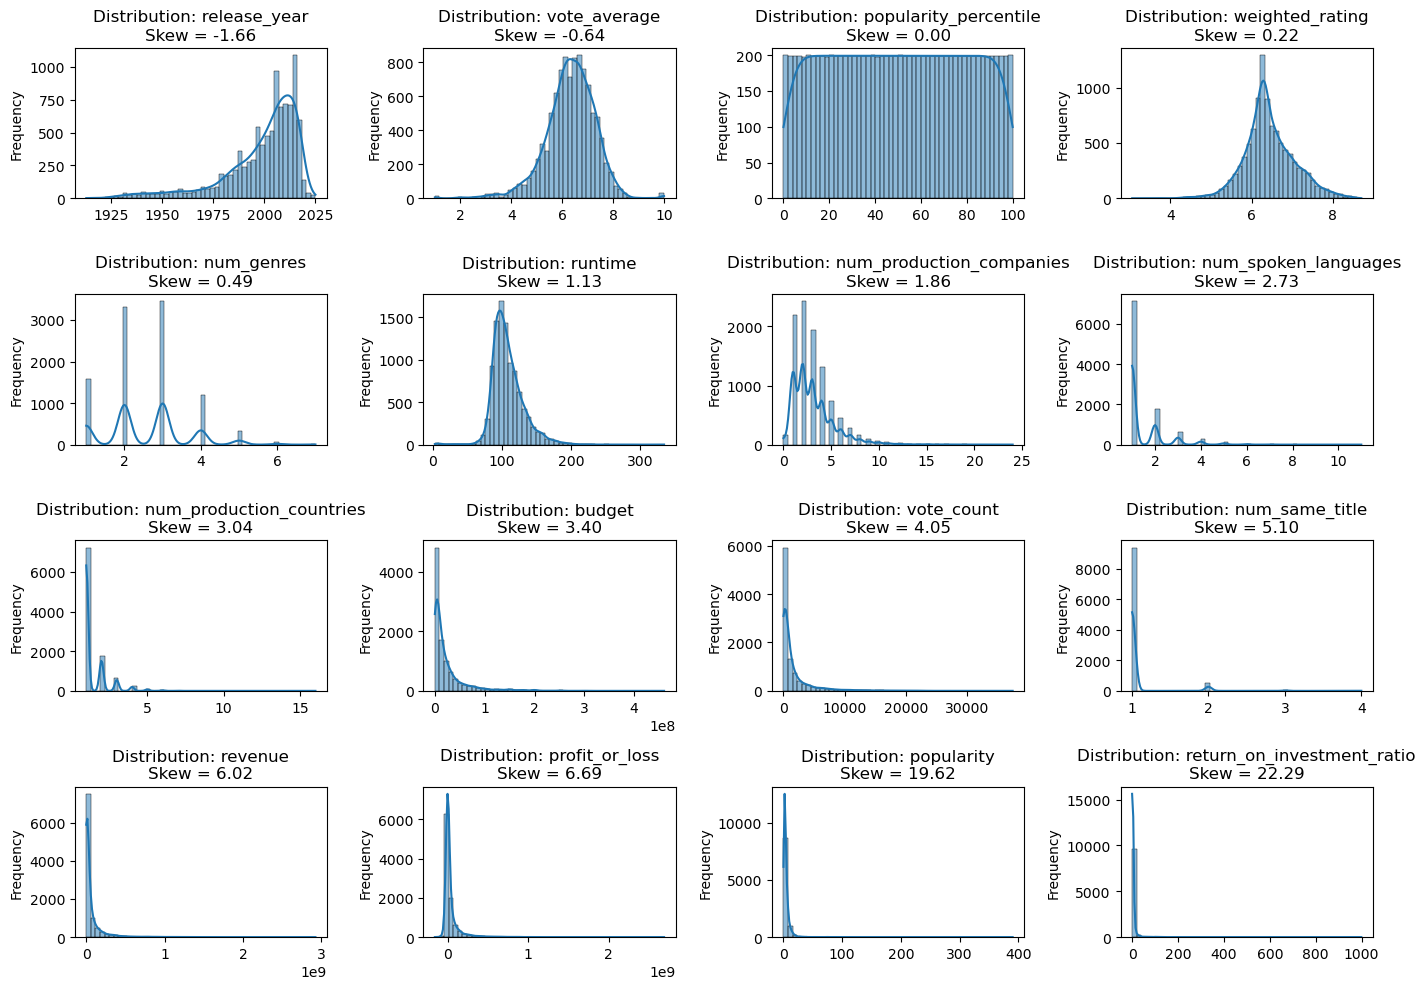

In [78]:
feature_skewness = data_clean.skew().sort_values(ascending=True)

plt.figure(figsize=(14, 10))
for i, feature in enumerate(feature_skewness.index[:16]):
    plt.subplot(4, 4, i+1)
    sns.histplot(data_clean[feature], bins=50, kde=True)
    plt.title(f'Distribution: {feature}\nSkew = {feature_skewness[feature]:.2f}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [79]:
# log transformation for skewed features: (skewness > 1.85)
skewed_cols = feature_skewness[feature_skewness > 1.85].index

data_clean[skewed_cols] = np.log1p(data_clean[skewed_cols])

In [80]:
scaler = StandardScaler()
scaled_clean_data = scaler.fit_transform(data_clean)

In [81]:
data_clean.dtypes

runtime                         int64
budget                        float64
revenue                       float64
popularity                    float64
vote_average                  float64
vote_count                    float64
num_same_title                float64
num_genres                      int64
num_production_companies      float64
num_production_countries      float64
num_spoken_languages          float64
popularity_percentile         float64
weighted_rating               float64
release_year                    int64
return_on_investment_ratio    float64
profit_or_loss                float64
dtype: object

## ⚙️ Question Ensembling

With our cleaned and preprocessed dataset, we aim to formulate a set of guiding questions that will allow us to **compare the performance and behavior of different clustering algorithms**. These questions are designed to reveal **distinct patterns and insights** that may emerge depending on the algorithm applied.

Beyond algorithmic comparison, we also want these questions to uncover **practical insights** that can inform future decisions or analyses.

### 🎯 Our Three Guiding Questions:

1. **Commercial Success Patterns**  
   → Can we identify groupings of movies based on financial success (e.g., budget, revenue, profitability)?

2. **Structural Attribute Patterns**  
   → Do common traits or structural characteristics (e.g., runtime, release year) define each cluster?

3. **Public Critique Patterns**  
   → How do clusters differ in terms of audience reception, ratings or critical acclaim?

---

## 🧩 Question 1: Commercial Success Patterns

**❓ Question:**  
Can we identify groupings of movies based on financial success?

**🎯 Goal:**  
Use clustering algorithms to discover natural groupings of movies based on financial metrics (budget and revenue),  
and interpret whether these groupings reveal insights about commercial performance.

#### Feature Selection – Financial Performance Indicators:


| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `budget`                  | 	The production cost of the movie – a proxy for investment. |
| `revenue`             | 	The total box office income – a proxy for public demand and commercial success. |

In [82]:
selected_features = [
    'budget',
    'revenue'
]

X = data_clean[selected_features].copy()

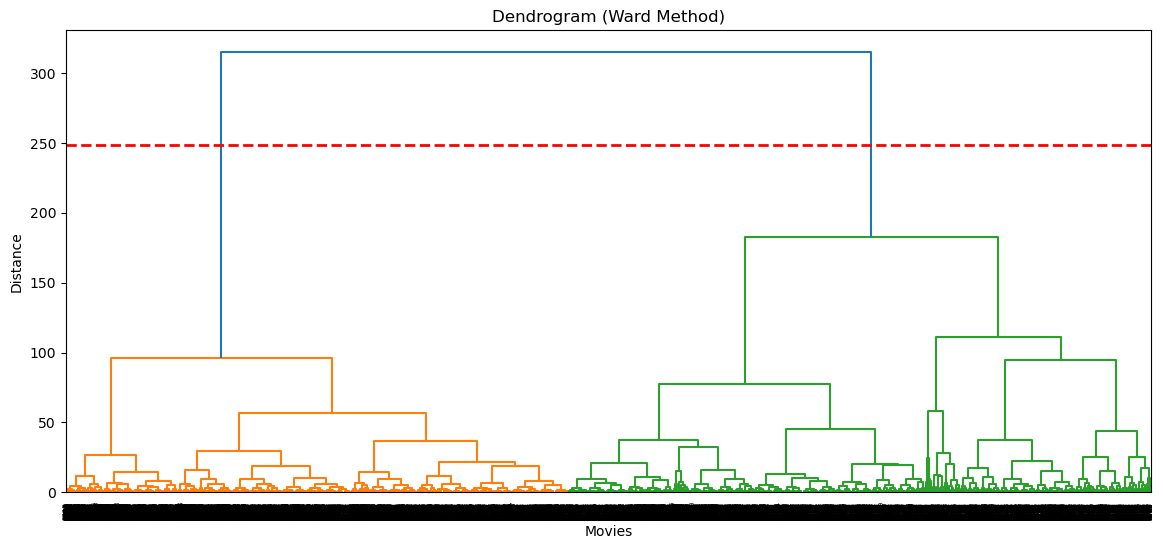

In [83]:
# Hierarchical Clustering:
linkage_matrix = linkage(X, method='ward')

merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

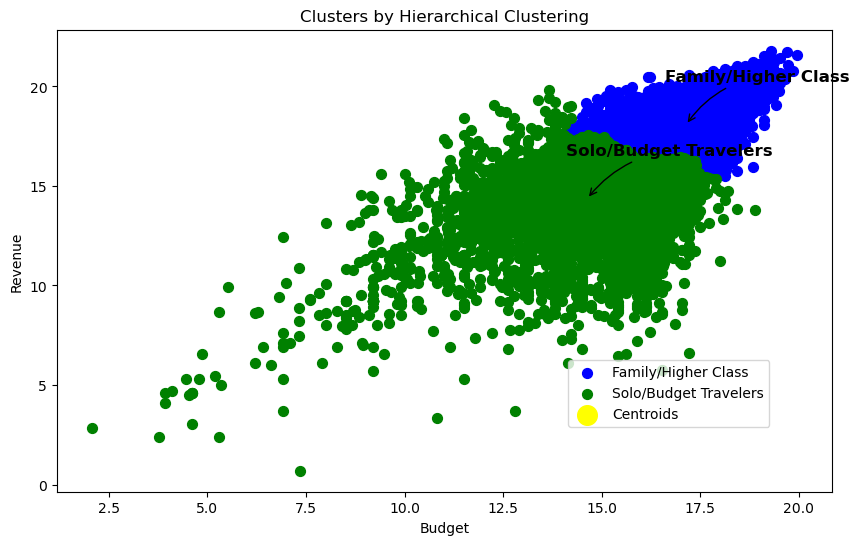

Hierarchical Clustering Metrics:
Silhouette Score: 0.4261
Davies-Bouldin Score: 0.7928
Dunn Index: 0.2180
Calinski-Harabasz Score: 9656.2043


In [84]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

# Scatter plot for hierarchical clusters
plt.figure(figsize=(10,6))
labels = ['Family/Higher Class', 'Solo/Budget Travelers']

# Convert DataFrame to numpy array for indexing
X_array = X.values

# Plot clusters
plt.scatter(X_array[hier_labels == 1, 0], X_array[hier_labels == 1, 1], 
            s=50, c='blue', label=labels[0], zorder=3)
plt.scatter(X_array[hier_labels == 2, 0], X_array[hier_labels == 2, 1], 
            s=50, c='green', label=labels[1], zorder=3)

# Compute cluster centers
centers = X.groupby(hier_labels).mean().values

# Plot centers
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', 
            label='Centroids', zorder=1)

# Plot annotations
for label, x, y in zip(labels, centers[:, 0], centers[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-15, 40),
                 va='top', fontsize=12, fontweight='bold', 
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle='arc3,rad=0.2'))

plt.title('Clusters by Hierarchical Clustering')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=[0.65, 0.3])
plt.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

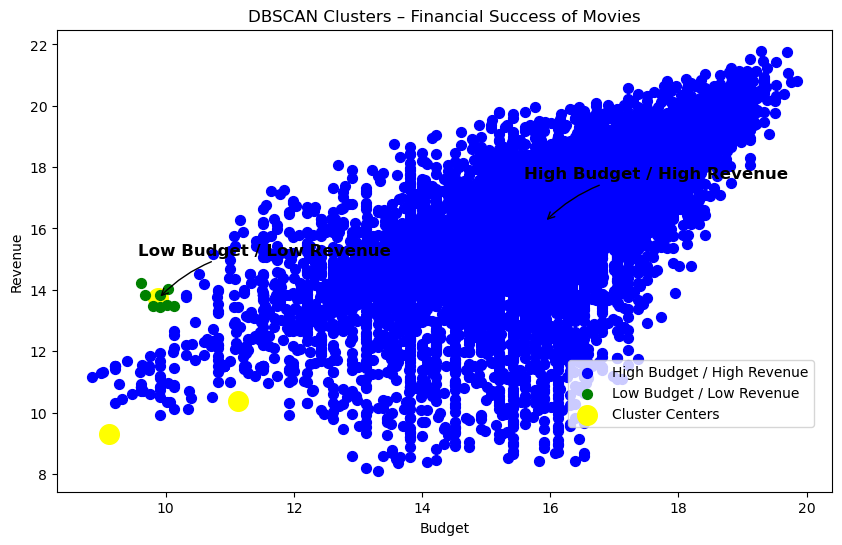

DBSCAN Clustering Metrics:
Silhouette Score: 0.4210
Davies-Bouldin Score: 0.3720
Dunn Index: 0.1474
Calinski-Harabasz Score: 150.3584


In [85]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)

# Filter out noise points (label -1)
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# Prepare cluster labels manually based on visual inspection
labels = ['High Budget / High Revenue', 'Low Budget / Low Revenue']  # Update as needed

# Convert to numpy for indexing
X_core_array = X_core.values

# Plot DBSCAN clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_core_array[labels_core == 0, 0], X_core_array[labels_core == 0, 1],
            s=50, c='blue', label=labels[0], zorder=3)
plt.scatter(X_core_array[labels_core == 1, 0], X_core_array[labels_core == 1, 1],
            s=50, c='green', label=labels[1], zorder=3)

# Compute cluster centers
centers = X_core.groupby(labels_core).mean().values

# Plot centers
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', 
            label='Cluster Centers', zorder=1)

# Annotate clusters
for label, x, y in zip(labels, centers[:, 0], centers[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-15, 40),
                 va='top', fontsize=12, fontweight='bold', 
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', connectionstyle='arc3,rad=0.2'))

plt.title('DBSCAN Clusters – Financial Success of Movies')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=[0.65, 0.3])
plt.show()

sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)
print(f"DBSCAN Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

In [86]:
# KMeans Clustering:




### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| **Best Value ✅**                |      1            |         0             |    ∞        |        ∞                |
| **Worst Value ❌**                |      -1            |         ∞             |    0        |        0                |
| **Hierarchical**              |      0.331        |         0.9630        |    0.1464   |        5144.6364        |
| **DBSCAN**                    |      -0.5640      |         2.7779        |    0.0031   |        5.0204           |
| **KMeans**                    |                   |                       |             |                         |


___
## 🧩 Question 2: Structural Attribute Patterns

**❓ Question:**  
Are there structural groupings among the movies — based on features such as runtime, release year or number of genres — that do not necessarily relate to quality or commercial success?

**🎯 Goal:**  
To explore whether movies can be clustered according to **structural attributes** rather than content or performance. These attributes may reveal latent patterns in how movies are produced or categorized over time.

This question is particularly useful for testing whether clustering algorithms can uncover **hidden structural trends** in the dataset that aren't explicitly tied to audience reception or box office revenue.

#### Feature Selection – Structural Movie Characteristics:

| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `runtime`                  | Indicates the length of the movie – may help identify clusters of short vs. long films. |
| `release_year`             | Reflects the era of release. Movies from similar periods may share production trends or stylistic patterns. |
| `budget`                   | Budget size represents the scale of production – high-budget vs. low-budget films may form distinct groups. |
| `num_genres`               | A movie with multiple genres may differ in structure or marketing from single-genre films. |
| `num_production_companies` | A high number may indicate complex or large-scale productions; low values may imply indie films. |
| `num_production_countries` | International co-productions may share characteristics distinct from single-country productions. |
| `num_spoken_languages`     | Multi-language films may target global audiences and differ structurally from single-language films. |

In [87]:
selected_features = [
    'runtime',
    'release_year',
    'budget',
    'num_genres',
    'num_production_companies',
    'num_production_countries',
    'num_spoken_languages'
]

X = data_clean[selected_features].copy()


In [88]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

In [89]:
explained_var = pca.explained_variance_ratio_
total_var = explained_var.sum()
print(f"Total variance explained (2D): {total_var:.2%}")

Total variance explained (2D): 99.46%


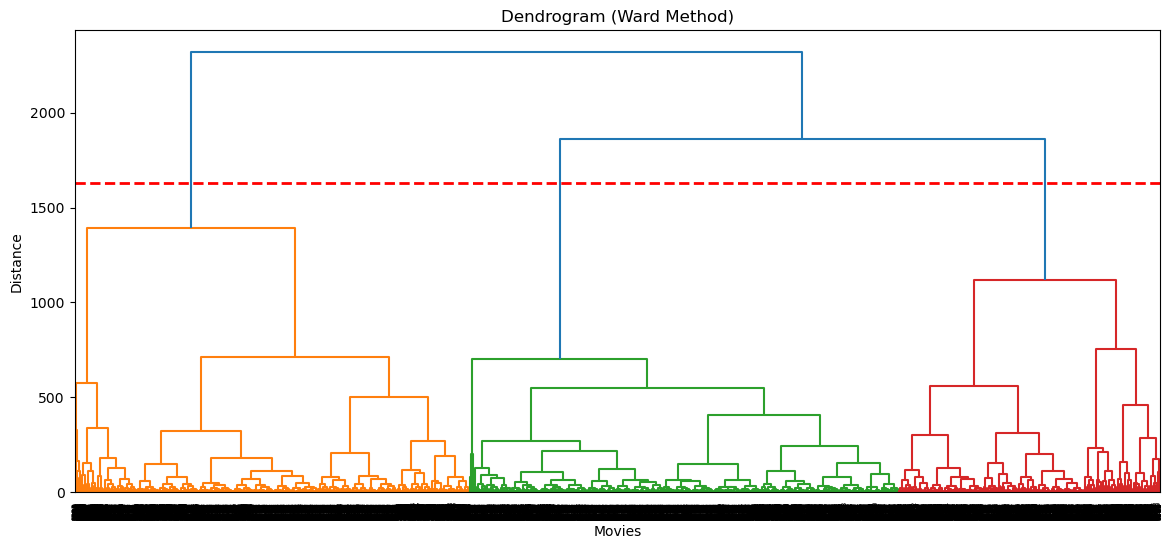

In [90]:
# Hierarchical Clustering: (we will use the Ward method for linkage becuase it is more common and fits well with most datasets)
linkage_matrix = linkage(X, method='ward')

# cutting the dendrogram to find the optimal number of clusters - we will use the maximum gap method
merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [91]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

data_clean['cluster_hierarchical'] = hier_labels.astype(str)

data_clean['pca_1'] = pca_result[:, 0]
data_clean['pca_2'] = pca_result[:, 1]

fig = px.scatter(
    data_clean,
    x='pca_1',
    y='pca_2',
    color='cluster_hierarchical',
    title="2D PCA – Hierarchical Clustering",
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")


Hierarchical Clustering Metrics:
Silhouette Score: 0.3317
Davies-Bouldin Score: 0.9630
Dunn Index: 0.1464
Calinski-Harabasz Score: 5144.6364


In [92]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(pca_result)

data_clean['cluster_dbscan'] = dbscan_labels.astype(str)
data_clean['pca_1'] = pca_result[:, 0]
data_clean['pca_2'] = pca_result[:, 1]

# Plot
fig = px.scatter(
    data_clean,
    x='pca_1',
    y='pca_2',
    color='cluster_dbscan',
    title="2D PCA – DBSCAN Clustering",
    opacity=0.7
)
fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

# === Filter out noise points ===
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# === Clustering Metrics (Core Points Only) ===
sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)

print(f"DBSCAN Clustering Metrics (Core Points Only):\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

DBSCAN Clustering Metrics (Core Points Only):
Silhouette Score: 0.0806
Davies-Bouldin Score: 2.6455
Dunn Index: 0.0607
Calinski-Harabasz Score: 166.5205


In [93]:
# KMeans Clustering:




### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| **Best Value ✅**                |      1            |         0             |    ∞        |        ∞                |
| **Worst Value ❌**                |      -1            |         ∞             |    0        |        0                |
| **Hierarchical**              |      0.331        |         0.9630        |    0.1464   |        5144.6364        |
| **DBSCAN**                    |      -0.5640      |         2.7779        |    0.0031   |        5.0204           |
| **KMeans**                    |                   |                       |             |                         |


___
## 🧩 Question 3: Public Critique Patterns

**❓ Question:**  
Is There a Natural Clustering of Movies Based on Critical/Audience Reception?

**🎯 Goal:**  
The goal is to determine whether a natural clustering of movies exists based on how they were received by audiences and critics and  
to examine whether movies can be grouped based on different levels of *perceived quality*, as reflected in quantitative data.

#### Feature Selection – Public Reception Metrics:

| Feature                     | Reason for Inclusion |
|----------------------------|----------------------|
| `vote_average`                  | Captures the average rating given by users – a direct indicator of audience-perceived quality. |
| `popularity`             | Reflects general public interest, combining views, searches, and engagement – often correlated with cultural relevance. |
| `vote_count`                   | 	Indicates the volume of audience participation – movies with high vote counts tend to have broader exposure or impact. |

In [94]:
selected_features = [
    'vote_average',
    'popularity',
    'vote_count',
]

X = data_clean[selected_features].copy()

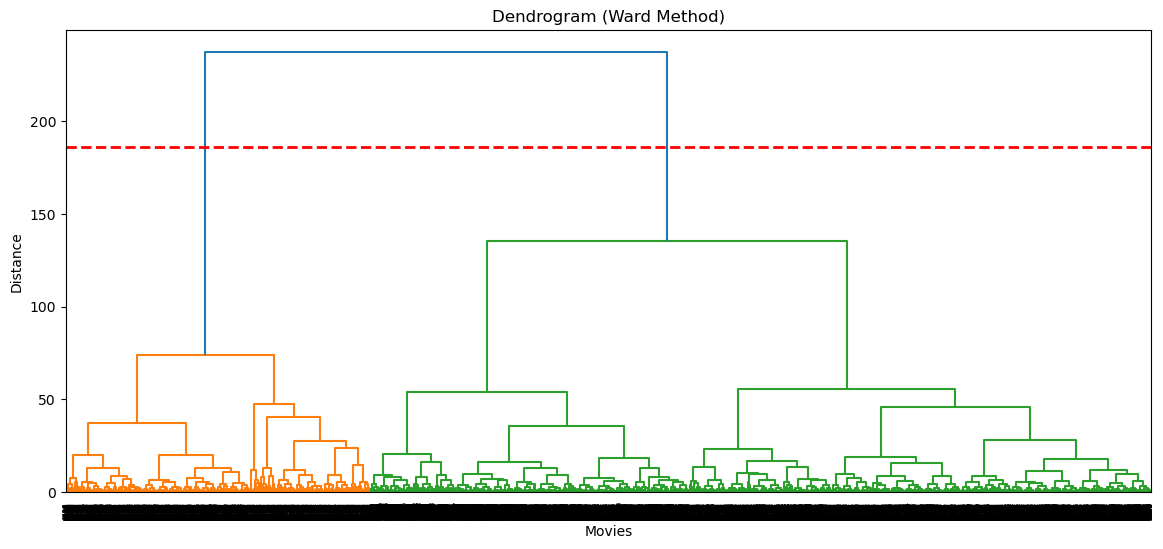

In [95]:
# Hierarchical Clustering:
linkage_matrix = linkage(X, method='ward')

merge_heights = linkage_matrix[:, 2]
gaps = np.diff(merge_heights)
max_gap_index = np.argmax(gaps)
cut_height = (merge_heights[max_gap_index] + merge_heights[max_gap_index + 1]) / 2

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.axhline(y=cut_height, color='red', linestyle='--', linewidth=2)
plt.title("Dendrogram (Ward Method)")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [96]:
hier_labels = fcluster(linkage_matrix, t=cut_height, criterion='distance')

data_clean['cluster_hierarchical'] = hier_labels.astype(str)

fig = px.scatter_3d(
    data_clean,
    x='vote_average',
    y='vote_count',
    z='popularity',
    color='cluster_hierarchical',
    title='3D Hierarchical Clustering',
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

sil_score = silhouette_score(X, hier_labels)
db_score = davies_bouldin_score(X, hier_labels)
dunn_score = dunn_index(X, hier_labels)
cal_score = calinski_harabasz_score(X, hier_labels)
print(f"Hierarchical Clustering Metrics:\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")


Hierarchical Clustering Metrics:
Silhouette Score: 0.4587
Davies-Bouldin Score: 0.7792
Dunn Index: 0.4068
Calinski-Harabasz Score: 10527.9892


In [97]:
# DBSCAN Clustering:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

data_clean['cluster_dbscan'] = dbscan_labels.astype(str)

fig = px.scatter_3d(
    data_clean,
    x='vote_average',
    y='vote_count',
    z='popularity',
    color='cluster_dbscan',
    title='3D DBSCAN Clustering',
    opacity=0.7
)

fig.update_layout(margin=dict(l=20, r=20, b=20, t=60))
fig.show()

# === Filter out outliers ===
core_mask = dbscan_labels != -1
X_core = X[core_mask]
labels_core = dbscan_labels[core_mask]

# === Clustering Metrics (Core Points Only) ===
sil_score = silhouette_score(X_core, labels_core)
db_score = davies_bouldin_score(X_core, labels_core)
dunn_score = dunn_index(X_core, labels_core)
cal_score = calinski_harabasz_score(X_core, labels_core)

print(f"DBSCAN Clustering Metrics (Core Points Only):\n"
      f"Silhouette Score: {sil_score:.4f}\n"
      f"Davies-Bouldin Score: {db_score:.4f}\n"
      f"Dunn Index: {dunn_score:.4f}\n"
      f"Calinski-Harabasz Score: {cal_score:.4f}")

DBSCAN Clustering Metrics (Core Points Only):
Silhouette Score: 0.5398
Davies-Bouldin Score: 0.3124
Dunn Index: 0.5463
Calinski-Harabasz Score: 171.1295


In [98]:
# KMeans Clustering:


### **Performance Comparison:**  

| Model                         | Silhouette Score  | Davies-Bouldin Score  | Dunn Index  | Calinski-Harabasz Score |
|-------------------------------|-------------------|-----------------------|-------------|-------------------------|
| **Best Value ✅**                |      1            |         0             |    ∞        |        ∞                |
| **Worst Value ❌**                |      -1            |         ∞             |    0        |        0                |
| **Hierarchical**              |      0.6146        |         0.5146        |    0.9420   |        28889.63934        |
| **DBSCAN**                    |      -0.2686      |         2.6931        |    0.0096   |        986.5018           |
| **KMeans**                    |                   |                       |             |                         |

---

In [99]:
# import plotly.express as px


# def plot_clusters(data, feature_list, cluster_column='cluster'):
#     """
#     מציג גרף קלסטרינג תלת־ממדי או דו־ממדי לפי כמות הפיצרים.
#     מציג רק את הערכים המקוריים (עם סיומת _orig) בתוך ההובר.
#     """

#     # שימוש בדו־ממדי עם seaborn
#     if len(feature_list) == 2:
#         plt.figure(figsize=(10, 6))
#         sns.scatterplot(
#             data=data,
#             x=feature_list[0],
#             y=feature_list[1],
#             hue=cluster_column,
#             palette='Set2',
#             s=60
#         )
#         plt.title(f"2D Cluster Plot: {feature_list[0]} vs {feature_list[1]}")
#         plt.xlabel(feature_list[0])
#         plt.ylabel(feature_list[1])
#         plt.margins(x=0.1, y=0.1)
#         plt.tight_layout()
#         plt.legend(title='Cluster')
#         plt.show()

#     elif len(feature_list) == 3:
#         # עמודות מקוריות שנרצה להציג ב-hover
#         hover_cols = [col + '_orig' for col in feature_list if col + '_orig' in data.columns]

#         fig = px.scatter_3d(
#             data,
#             x=feature_list[0],
#             y=feature_list[1],
#             z=feature_list[2],
#             color=cluster_column,
#             hover_data=hover_cols,
#             opacity=0.7,
#             title=f"3D Cluster Plot: {feature_list[0]} / {feature_list[1]} / {feature_list[2]}"
#         )

#         # ניצור hovertemplate שמכיל את שם הפיצ'ר עבור כל עמודת hover
#         hovertemplate = '<br>'.join([
#             f'{col}: %{{customdata[{i}]}}' for i, col in enumerate(hover_cols)
#         ])

#         fig.update_traces(hovertemplate=hovertemplate)

#         fig.update_layout(
#             margin=dict(l=20, r=20, b=20, t=60),
#             scene=dict(
#                 xaxis=dict(title=feature_list[0], tickfont=dict(size=12)),
#                 yaxis=dict(title=feature_list[1], tickfont=dict(size=12)),
#                 zaxis=dict(title=feature_list[2], tickfont=dict(size=12)),
#                 aspectmode='manual',
#                 aspectratio=dict(x=1.3, y=1.1, z=0.9)
#             ),
#             scene_camera=dict(
#                 eye=dict(x=1.5, y=1.5, z=3)
#             )
#         )

#         fig.show()


#     else:
#         print("❌ This function only supports 2 or 3 features.")



# # plot_clusters(filtered_data, list_a)

# plot_clusters(data_cluster, list_a)




כל מה שלמטה לא לגעת

In [100]:
# # 🔹 שלב 10: ניתוח הקלאסטרים
# cluster_medians = data.groupby('cluster')[['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime', 'return_on_investment_ratio']].median()
# display(cluster_medians)
# #פרשנות וניתוח
# #לההראות שעשיתי ממוצע ואז העברתי לחציון ולמה

In [101]:
# # 🔹 שלב 11: הצגת דוגמאות לכל קלאסטר (כולל שם הסרט)
# columns_to_show = ['title', 'budget', 'revenue', 'vote_average', 'popularity', 'return_on_investment_ratio']
# for c in sorted(data['cluster'].unique()):
#     print(f"\n=== Cluster {c} ===")
#     display(data[data['cluster'] == c][columns_to_show].sample(5, random_state=42))


להוסיף מסקנות וכאלה 

In [102]:
# data_cluster['cluster'].value_counts()


 שלב 9: כתיבת סיכום תובנות
 כתבי פסקה אחת על מה למדת מכל קלאסטר (מי הקבוצות, במה הן שונות)

 קשרי את הקלאסטרים לדפוסים קולנועיים מוכרים (למשל: "סרטים נישתיים מצליחים" או "סרטים עתירי תקציב עם דירוג נמוך")